<a href="https://colab.research.google.com/github/Sujal9858/SujalGit/blob/main/Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#Multiple Linear Regression Analysis of Production Costs
#Glen Mason
#Week 2 MOD008912

In [5]:
#Decalre Reference to General Libraries
import pandas as pd #Used to manipulate data sets (derived from PaNel DAta) pd is an alias
import numpy as np #Used to work with arrays (e.g. useful for I/O validation)
import matplotlib.pyplot as plt #Used to generate statistical illustrations e.g graphs
import seaborn as sns #A more sophisticated version of matplotlib
#Import Special Data Analysis Packages
from sklearn.model_selection import train_test_split #Used to split the data set
from sklearn.linear_model import LinearRegression #Selected modelling algorythim
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error #Performance metrics

In [17]:
#Read and Display Data Set
#First, read in CSV file and assign it to a variable called "data"
data = pd.read_csv('USA_Housing_Data.csv')
#Second, display maximum rows and columns
print('\nRows Columns') #indicates rows and columns
print(data.shape) #gets the number of rows and columns of data set
#Third, display first 5 x rows to check data
print(data.head(5))


Rows Columns
(5000, 6)
        Income  House Age     Rooms  Bedrooms   Population         Price
0  79545.45857   5.682861  7.009188      4.09  23086.80050  1.059034e+06
1  79248.64245   6.002900  6.730821      3.09  40173.07217  1.505891e+06
2  61287.06718   5.865890  8.512727      5.13  36882.15940  1.058988e+06
3  63345.24005   7.188236  5.586729      3.26  34310.24283  1.260617e+06
4  59982.19723   5.040555  7.839388      4.23  26354.10947  6.309435e+05


Axes(0.125,0.11;0.62x0.77)


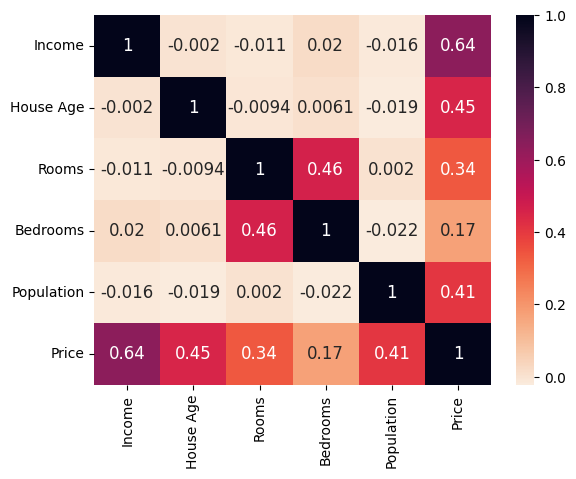

In [16]:
#Display Feature Relations of Data Set
print(sns.heatmap(data.corr(),annot=True,annot_kws={"size":12}, cmap = sns.cm.rocket_r))

In [21]:
#Declare X and Y Variables and Split the Dataset into Train and Test sections
X=data.drop(['Price'],axis=1).values #X variables = all common except the last one
#Declare last column to be the dependent variable Y
y=data['Price']
#Split Data Set 70% training and 30% Testing. Initial data shuffle to zero
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.7,test_size = 0.3, random_state=0)

In [22]:
#Create and Test the Model
#First declare a new model
linear_model = LinearRegression()
#Second Train (fit) the model from the training data
linear_model.fit(X_train,y_train)
#Third get Coefficients
print('\nIntercept = ',linear_model.intercept_) #Find Bias Intercept
print('\nCoefficients = ',linear_model.coef_) # Find Weightings (gradients) of features
#Fourth make some predictions
y_predict = linear_model.predict(X_test)
print('\nTest Data Model Predictions',y_predict)


Intercept =  -2644788.97741453

Coefficients =  [2.16187374e+01 1.66145180e+05 1.21010577e+05 1.76003779e+03
 1.51647974e+01]

Test Data Model Predictions [ 969608.34686739  953868.15550975  907506.32824813 ... 1423701.02106516
  744400.93306006  488525.83115773]


R-squared: 0.9200757649506058
Mean Absolute Error: 81563.14732603596
Mean Squared Error: 10337337827.049204
Root Mean Squared Error: 101672.69951687721


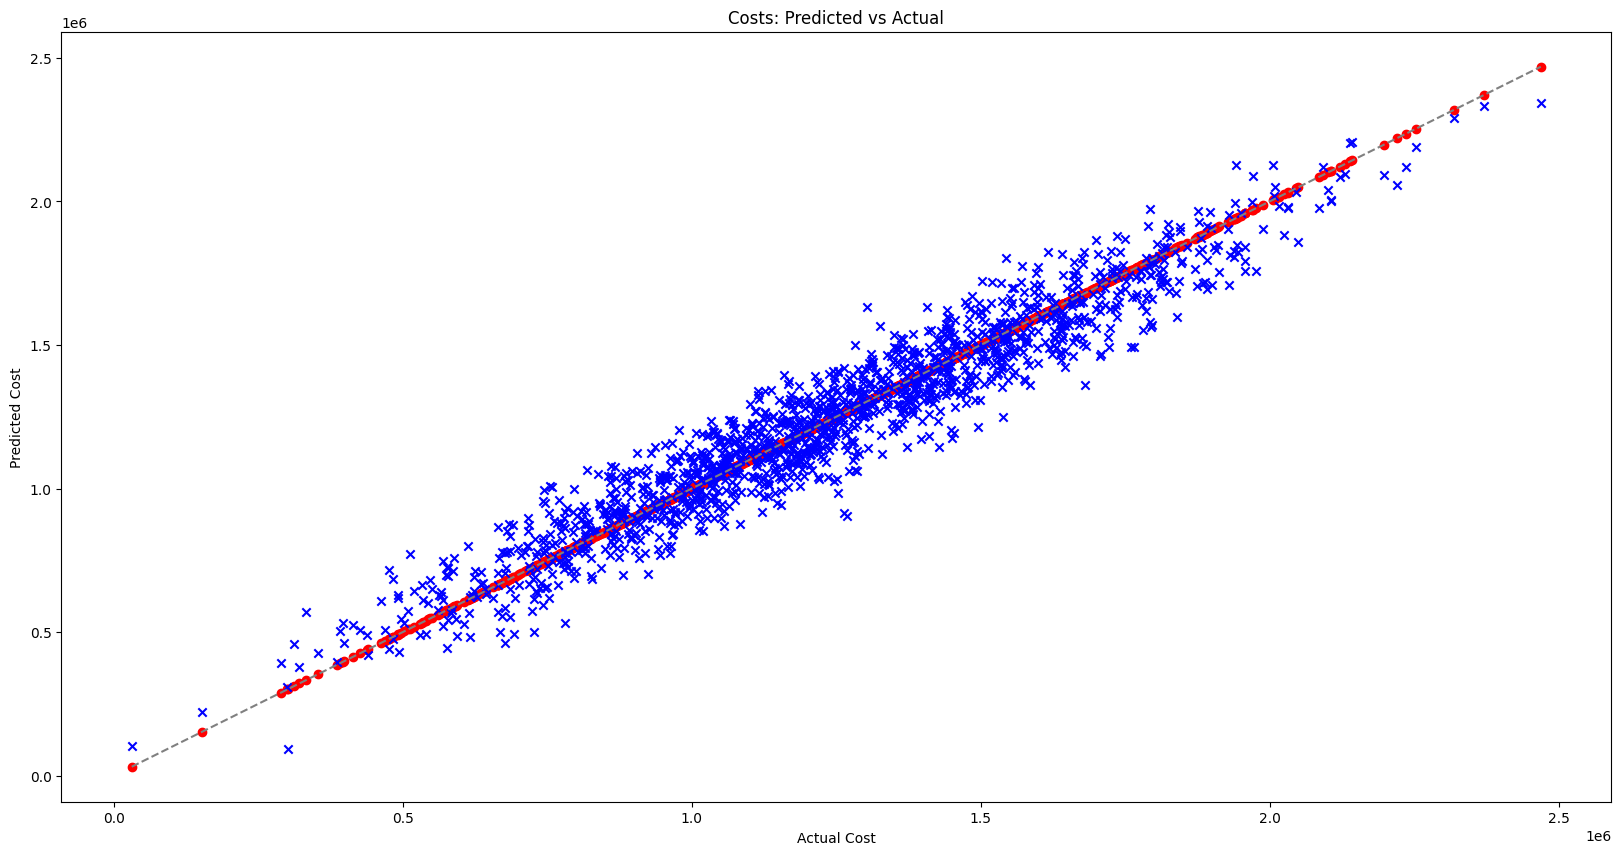

In [23]:
#Evaluate the model
#First Plot Actual vs Predicted
plt.figure(figsize=(20,10))
plt.title("Costs: Predicted vs Actual")
plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.scatter(y_test,y_test, c='red',marker='o', label = 'Actual Values')
plt.scatter(y_test,y_predict, c='blue', marker='x', label ='Predicted Values')
#Add a diagonal line for reference (perfect prediction)
plt.plot([min(y_test),max(y_test)], [min(y_test), max(y_test)], linestyle='--',color='gray')
#Second Calculate Performance Metrics
r_squared = r2_score(y_test, y_predict) #R-squared value (how well the model fits 0-1)
print(f"R-squared: {r_squared}")
mean_abs = mean_absolute_error(y_test, y_predict)
print(f"Mean Absolute Error: {mean_abs}")
mean_sqr = mean_squared_error(y_test, y_predict)
print(f"Mean Squared Error: {mean_sqr}")
root_mean_sqr = root_mean_squared_error(y_test, y_predict)
print(f"Root Mean Squared Error: {root_mean_sqr}")

In [25]:
#Validate the model with own (unseen) test data
Product_Units = []
print("\nEnter values for independent variables:")
#Collect user input for each feature by:
#Retrieve column names from data frame
#Read in the user input
#Write and update a list
for i, column_name in enumerate(data.columns[:-1]):
    value = float(input(f"{column_name}: "))
    Product_Units.append(value)
#Convert costs to numpy array and reshape it to (1, -1) 2D array
Product_Units = np.array(Product_Units).reshape(1,-1)
#Predict the cost using the Linear Regression Model
predicted_cost = linear_model.predict(Product_Units)
print(f"\nPredicted Cost: {predicted_cost[0]}")


Enter values for independent variables:
Income: 65000
House Age: 6
Rooms: 7
Bedrooms: 4
Population: 30000

Predicted Cost: 1066358.1404518774
